# MLP Autoencoder

Second model and the first neural network here. Idea is to train an autoencoder only on empty windows so it learns to rebuild normal data well. When it sees an occupied window it never saw before it rebuilds it badly, and that reconstruction error is the anomaly score. Same logic as Isolation Forest (learn normal, flag the unfamiliar) but a neural net learns normal instead of random cuts.

Architecture: flatten the 30x2 window to 60, then 60 -> 32 -> 16 -> 8 bottleneck -> 16 -> 32 -> 60. Loss is MSE between input and output.

## Load the prepared data

Same windows from notebook 1. They are raw so I normalize here with train stats only.

In [1]:
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

data = np.load('../data/prepared.npz')
X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_test  = data['y_test']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("test empty:", (y_test==0).sum(), " occupied:", (y_test==1).sum())

X_train: (2105, 30, 2)
X_test: (1551, 30, 2)
test empty: 452  occupied: 1099


## Normalize and flatten

z-score from train only, then flatten each (30,2) window into a flat vector of 60 so the MLP can take it.

In [2]:
train_mean = X_train.mean(axis=(0,1))
train_std  = X_train.std(axis=(0,1))

def norm(x): return (x - train_mean) / (train_std + 1e-8)

Xtr = norm(X_train).reshape(len(X_train), -1)
Xva = norm(X_val).reshape(len(X_val), -1)
Xte = norm(X_test).reshape(len(X_test), -1)

print("flattened train:", Xtr.shape)   # (n, 60)
print("flattened test:", Xte.shape)

# to tensors
Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
Xva_t = torch.tensor(Xva, dtype=torch.float32)
Xte_t = torch.tensor(Xte, dtype=torch.float32)

flattened train: (2105, 60)
flattened test: (1551, 60)


## Define the autoencoder

Encoder squeezes 60 down to 8, decoder brings it back to 60. ReLU between layers. Nothing fancy, small on purpose so it doesn't just memorize everything.

In [3]:
class MLPAutoencoder(nn.Module):
    def __init__(self, in_dim=60):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, in_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = MLPAutoencoder(in_dim=Xtr_t.shape[1])
print(model)

MLPAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=60, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=60, bias=True)
  )
)


## Train

Train on empty windows only. MSE loss, Adam. I watch validation loss (also empty) to make sure it's not overfitting. No labels used anywhere here, it's just learning to rebuild normal windows.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    out = model(Xtr_t)
    loss = loss_fn(out, Xtr_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t), Xva_t)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"epoch {epoch+1:3d}  train {loss.item():.4f}  val {val_loss.item():.4f}")

epoch  10  train 1.0050  val 1.3709
epoch  20  train 0.9894  val 1.3438
epoch  30  train 0.9461  val 1.2688
epoch  40  train 0.8324  val 1.0811
epoch  50  train 0.6273  val 0.7463
epoch  60  train 0.4502  val 0.4781
epoch  70  train 0.2461  val 0.2557
epoch  80  train 0.1394  val 0.1815
epoch  90  train 0.0952  val 0.1455
epoch 100  train 0.0807  val 0.1302


## Loss curves

Checking the model actually learned and val didn't blow up.

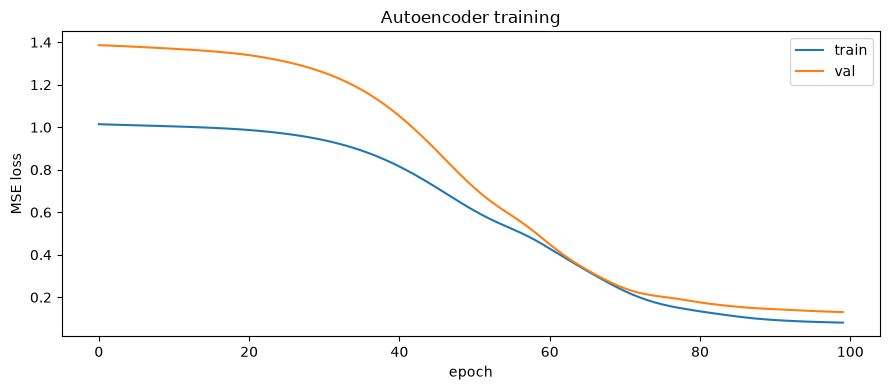

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.title('Autoencoder training')
plt.legend(); plt.tight_layout()
plt.savefig('../results/03_ae_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Anomaly score = reconstruction error

For each window I compute the MSE between input and output. High error means the model couldn't rebuild it, so it's probably occupied. Per-window error is the mean squared diff across the 60 values.

In [6]:
model.eval()
with torch.no_grad():
    val_recon  = model(Xva_t)
    test_recon = model(Xte_t)

# per-window reconstruction error
val_scores  = ((Xva_t - val_recon)**2).mean(dim=1).numpy()
test_scores = ((Xte_t - test_recon)**2).mean(dim=1).numpy()

print("val score range:", val_scores.min(), "to", val_scores.max())
print("test score range:", test_scores.min(), "to", test_scores.max())

val score range: 0.0046115434 to 1.6023155
test score range: 0.008720806 to 10.652506


## Threshold from validation

Same approach as Isolation Forest. Val is all empty so I take the 95th percentile of its errors as the threshold. Test windows above it are called occupied.

In [7]:
threshold = np.percentile(val_scores, 95)
print("threshold:", threshold)

y_pred = (test_scores > threshold).astype(int)
print("predicted occupied:", y_pred.sum(), "out of", len(y_pred))

threshold: 0.7481917
predicted occupied: 479 out of 1551


## Evaluate

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, test_scores)

print("precision:", round(prec,3))
print("recall:   ", round(rec,3))
print("f1:       ", round(f1,3))
print("roc-auc:  ", round(auc,3))
print("\nconfusion matrix:")
print(confusion_matrix(y_test, y_pred))

precision: 0.95
recall:    0.414
f1:        0.577
roc-auc:   0.884

confusion matrix:
[[428  24]
 [644 455]]


## Score distribution

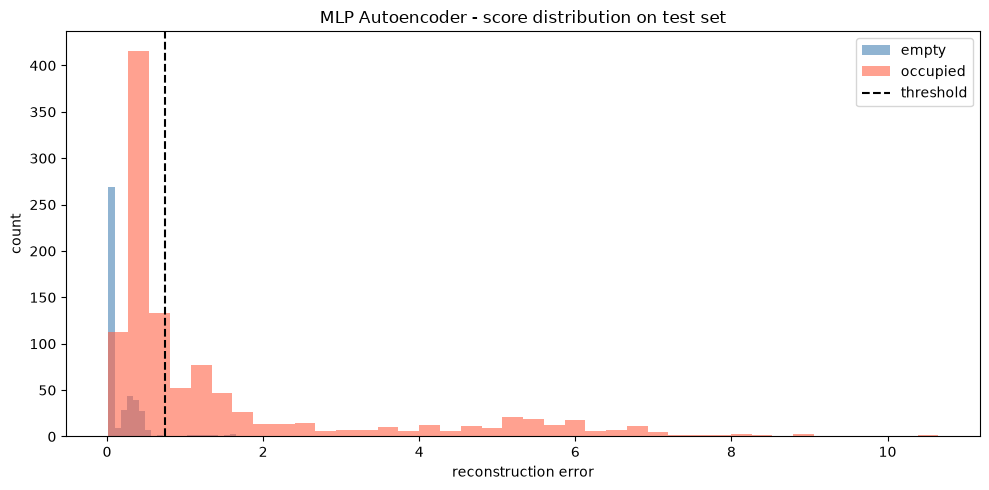

In [9]:
plt.figure(figsize=(10,5))
plt.hist(test_scores[y_test==0], bins=40, alpha=0.6, label='empty', color='steelblue')
plt.hist(test_scores[y_test==1], bins=40, alpha=0.6, label='occupied', color='tomato')
plt.axvline(threshold, color='black', linestyle='--', label='threshold')
plt.xlabel('reconstruction error'); plt.ylabel('count')
plt.title('MLP Autoencoder - score distribution on test set')
plt.legend(); plt.tight_layout()
plt.savefig('../results/03_ae_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Save scores

For the final 3-model comparison.

In [10]:
np.savez('../results/ae_scores.npz', test_scores=test_scores, y_test=y_test)
print("saved")

saved
